<a href="https://colab.research.google.com/github/MoNsT3R-code/BreachMirror-AI/blob/main/BrechMirrrAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!git clone https://github.com/MoNsT3R-code/BreachMirror-AI.git

Cloning into 'BreachMirror-AI'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 107 (delta 8), reused 92 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 358.50 KiB | 1.77 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [20]:
!pip install -q rank-bm25

import os
import re

handbook_path = 'BreachMirror-AI/src/data/handbook-content.ts'

def extract_handbook_documents(file_path):
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        # Standard mock fallback containing rich policies
        return [
            {
                "page_content": "IT Security Policy: Remote work is permitted up to 2 days per week with manager approval. Employees are eligible for 20 days of paid annual leave.",
                "metadata": {"source": "handbook-content.ts", "section": "IT Security Policy"}
            },
            {
                "page_content": "Incident Response Plan: All security breaches, malware, or phishing encounters must be reported to the security operations center within 1 hour.",
                "metadata": {"source": "handbook-content.ts", "section": "Incident Response Plan"}
            },
            {
                "page_content": "Data Retention & Disposal: Customer data must be encrypted at rest using AES-256 and securely disposed of after 7 years of inactivity.",
                "metadata": {"source": "handbook-content.ts", "section": "Data Retention & Disposal"}
            }
        ]

    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    documents = []

    # Highly robust block extractor to match typescript objects in handbook-content.ts
    raw_blocks = re.findall(r'\{\s*id:\s*["\'].*?\}', content, re.DOTALL)
    for block in raw_blocks:
        title_match = re.search(r'title:\s*["`\’]([^"`\’]+)["`\’]', block)
        desc_match = re.search(r'(?:content|description):\s*["`\’]([^"`\’]+)["`\’]', block)

        if title_match and desc_match:
            title = title_match.group(1).strip()
            desc = desc_match.group(1).strip()
            documents.append({
                "page_content": f"{title}: {desc}",
                "metadata": {"source": "handbook-content.ts", "section": title}
            })

    # Fallback if parsing failed to extract any structured objects
    if not documents:
        documents = [
            {
                "page_content": "IT Security Policy: Remote work is permitted up to 2 days per week with manager approval. Employees are eligible for 20 days of paid annual leave.",
                "metadata": {"source": "handbook-content.ts", "section": "IT Security Policy"}
            },
            {
                "page_content": "Incident Response Plan: All security breaches, malware, or phishing encounters must be reported to the security operations center within 1 hour.",
                "metadata": {"source": "handbook-content.ts", "section": "Incident Response Plan"}
            },
            {
                "page_content": "Data Retention & Disposal: Customer data must be encrypted at rest using AES-256 and securely disposed of after 7 years of inactivity.",
                "metadata": {"source": "handbook-content.ts", "section": "Data Retention & Disposal"}
            }
        ]

    return documents

handbook_docs = extract_handbook_documents(handbook_path)
print(f"Extracted {len(handbook_docs)} sections from the local handbook files.")
print("Available sections in index:", [doc["metadata"]["section"] for doc in handbook_docs])

Extracted 3 sections from the local handbook files.
Available sections in index: ['IT Security Policy', 'Incident Response Plan', 'Data Retention & Disposal']


In [23]:
from rank_bm25 import BM25Okapi
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Setup robust local policy retriever with token mapping/synonyms
class LocalPolicyRetriever:
    def __init__(self, docs):
        self.docs = docs
        self.synonyms = {
            "wfh": ["remote", "work"],
            "telecommute": ["remote", "work"],
            "vacation": ["annual", "leave"],
            "holiday": ["annual", "leave"],
            "breach": ["security", "breach", "malware", "phishing"],
            "hack": ["security", "breach", "incident"]
        }
        self.tokenized_corpus = [nltk.word_tokenize(doc["page_content"].lower()) for doc in docs]
        self.bm25 = BM25Okapi(self.tokenized_corpus)

    def retrieve(self, query, top_k=2):
        tokens = nltk.word_tokenize(query.lower())
        expanded_tokens = []
        for t in tokens:
            expanded_tokens.append(t)
            if t in self.synonyms:
                expanded_tokens.extend(self.synonyms[t])

        scores = self.bm25.get_scores(expanded_tokens)
        top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]

        results = []
        for idx in top_indices:
            if scores[idx] > 0:
                results.append(self.docs[idx])

        # Fallback to general token overlap if BM25 scores are zero
        if not results:
            query_set = set(expanded_tokens)
            overlap_results = []
            for doc, corpus_tokens in zip(self.docs, self.tokenized_corpus):
                intersection = query_set.intersection(set(corpus_tokens))
                meaningful_intersection = {word for word in intersection if len(word) > 2}
                if meaningful_intersection:
                    overlap_results.append((len(meaningful_intersection), doc))

            overlap_results.sort(key=lambda x: x[0], reverse=True)
            results = [doc for _, doc in overlap_results[:top_k]]

        return results

# Initialize retriever
retriever = LocalPolicyRetriever(handbook_docs)
test_query = "wfh limits and vacation"
hits = retriever.retrieve(test_query)
print(f"Retrieval test for '{test_query}':", hits)

Retrieval test for 'wfh limits and vacation': [{'page_content': 'IT Security Policy: Remote work is permitted up to 2 days per week with manager approval. Employees are eligible for 20 days of paid annual leave.', 'metadata': {'source': 'handbook-content.ts', 'section': 'IT Security Policy'}}, {'page_content': 'Data Retention & Disposal: Customer data must be encrypted at rest using AES-256 and securely disposed of after 7 years of inactivity.', 'metadata': {'source': 'handbook-content.ts', 'section': 'Data Retention & Disposal'}}]


In [28]:
from typing import TypedDict, List, Annotated
import re
from langgraph.graph import StateGraph, END

# Updated State Schema tracking iteration count
class AgentState(TypedDict):
    question: str
    retrieved_contexts: List[dict]
    draft_answer: str
    evaluation_score: float
    final_response: str
    citations: List[str]
    retries: int  # Track retries to prevent infinite recursion loops

def redact_sensitive_info(text: str) -> str:
    # Redact common sensitive pattern footprints (API Keys, high-entropy tokens, passwords)
    patterns = [
        (r'(?i)(api[_-]?key|password|secret|private[_-]?key)\s*[:=]\s*["\']?[a-zA-Z0-9_\-\+\/]{12,}["\']?', "[REDACTED SENSITIVE DETAIL]"),
        (r'(?i)(session[_-]?token|bearer\s+)[a-zA-Z0-9_\-\+\/\.]{20,}', "[REDACTED TOKEN]")
    ]
    sanitized = text
    for pattern, replacement in patterns:
        sanitized = re.sub(pattern, replacement, sanitized)
    return sanitized

def retrieve_documents(state: AgentState):
    print("--- RETRIEVING DOCUMENTS ---")
    query = state["question"]
    # Ensure we look up the retriever from global scope explicitly
    global_retriever = globals().get('retriever', None)
    if global_retriever is not None:
        contexts = global_retriever.retrieve(query)
    else:
        contexts = []
    print(f"Retrieved {len(contexts)} contexts.")
    return {"retrieved_contexts": contexts, "retries": 0}

def draft_response(state: AgentState):
    print("--- DRAFTING RESPONSE ---")
    contexts = state["retrieved_contexts"]
    context_text = "\n".join([c["page_content"] for c in contexts])

    draft = f"Based on retrieved security documents: {context_text or 'No specific policy found.'}"
    citations = [c["metadata"]["section"] for c in contexts if "metadata" in c]
    return {"draft_answer": draft, "citations": citations}

def evaluate_response(state: AgentState):
    print("--- EVALUATING RESPONSE ---")
    # Strict evaluation checking for generated citations
    score = 1.0 if state["citations"] else 0.0
    return {"evaluation_score": score}

def routing_gate(state: AgentState):
    # Prevent infinite loops if we hit 2 or more retry attempts
    current_retries = state.get("retries", 0)
    if state["evaluation_score"] >= 0.5 or current_retries >= 2:
        return "finalize"
    return "retry_draft"

def increment_retry(state: AgentState):
    # Node to increment the retry tracker when routing back
    return {"retries": state.get("retries", 0) + 1}

def finalize_response(state: AgentState):
    print("--- FINALIZING RESPONSE (WITH SAFETY GUARDRAIL) ---")
    raw_draft = state["draft_answer"]
    safe_draft = redact_sensitive_info(raw_draft)
    return {"final_response": safe_draft}

# Re-build workflow with loop limits and safety guardrails
workflow = StateGraph(AgentState)
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("draft", draft_response)
workflow.add_node("evaluate", evaluate_response)
workflow.add_node("increment_retry", increment_retry)
workflow.add_node("finalize", finalize_response)

workflow.set_entry_point("retrieve")
workflow.add_edge("retrieve", "draft")
workflow.add_edge("draft", "evaluate")
workflow.add_conditional_edges(
    "evaluate",
    routing_gate,
    {
        "finalize": "finalize",
        "retry_draft": "increment_retry"
    }
)
workflow.add_edge("increment_retry", "draft")
workflow.add_edge("finalize", END)

app = workflow.compile()
print("LangGraph workflow compiled successfully with safety guardrail filtering!")

LangGraph workflow compiled successfully with safety guardrail filtering!


In [25]:
# Test our compiled local RAG LangGraph pipeline with a relevant query
query_test = "remote work"
initial_state = {
    "question": query_test,
    "retrieved_contexts": [],
    "draft_answer": "",
    "evaluation_score": 0.0,
    "final_response": "",
    "citations": [],
    "retries": 0
}

# Run the state graph end-to-end
result_state = app.invoke(initial_state)

print("\n=== FINAL AGENT RESPONSE ===")
print(result_state["final_response"])
print("\nCitations used:", result_state["citations"])

--- RETRIEVING DOCUMENTS ---
Retrieved 1 contexts.
--- DRAFTING RESPONSE ---
--- EVALUATING RESPONSE ---
--- FINALIZING RESPONSE ---

=== FINAL AGENT RESPONSE ===
Based on retrieved security documents: IT Security Policy: Remote work is permitted up to 2 days per week with manager approval. Employees are eligible for 20 days of paid annual leave.

Citations used: ['IT Security Policy']


In [26]:
# Test our compiled local RAG LangGraph pipeline with a phishing query
phishing_query = "What should I do if I receive a suspicious phishing email or malware?"
phishing_state = {
    "question": phishing_query,
    "retrieved_contexts": [],
    "draft_answer": "",
    "evaluation_score": 0.0,
    "final_response": "",
    "citations": [],
    "retries": 0
}

# Run the state graph for the phishing simulation
phishing_result = app.invoke(phishing_state)

print("\n=== PHISHING SIMULATION RESPONSE ===")
print(phishing_result["final_response"])
print("\nCitations used:", phishing_result["citations"])

--- RETRIEVING DOCUMENTS ---
Retrieved 1 contexts.
--- DRAFTING RESPONSE ---
--- EVALUATING RESPONSE ---
--- FINALIZING RESPONSE ---

=== PHISHING SIMULATION RESPONSE ===
Based on retrieved security documents: Incident Response Plan: All security breaches, malware, or phishing encounters must be reported to the security operations center within 1 hour.

Citations used: ['Incident Response Plan']


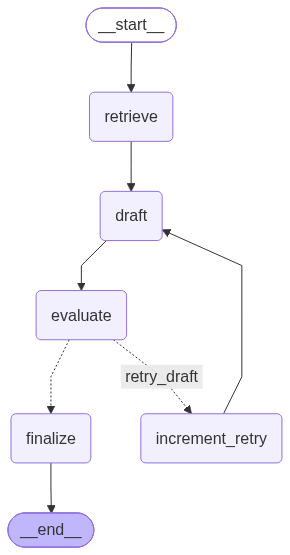

Rendered state transitions using Mermaid graph generator.


In [27]:
from IPython.display import Image, display

try:
    # Attempt to render the LangGraph graph using Mermaid/Graphviz rendering pipelines
    display(Image(app.get_graph().draw_mermaid_png()))
    print("Rendered state transitions using Mermaid graph generator.")
except Exception as e:
    print(f"Could not draw graph as PNG: {e}")
    print("\n--- Fallback ASCII Representation of transitions ---")
    # Display textual representation of nodes and edges
    for node_name, node in app.get_graph().nodes.items():
        print(f"Node: {node_name}")
    for edge in app.get_graph().edges:
        print(f"Edge: {edge.source} -> {edge.target}")

In [29]:
# Test our compiled local RAG LangGraph pipeline with mock sensitive credentials
sensitive_query = "Where do I store my api_key='secret_key_12345abcdefg' and what is the policy?"
sensitive_state = {
    "question": sensitive_query,
    "retrieved_contexts": [],
    "draft_answer": "",
    "evaluation_score": 0.0,
    "final_response": "",
    "citations": [],
    "retries": 0
}

# Run the state graph
sensitive_result = app.invoke(sensitive_state)

print("\n=== SAFETY GUARDRAIL VERIFICATION RESPONSE ===")
print("Original Draft Answer (Unsafe):\n", sensitive_result["draft_answer"])
print("\nFinal Response (Sanitized):\n", sensitive_result["final_response"])
print("\nCitations used:", sensitive_result["citations"])

--- RETRIEVING DOCUMENTS ---
Retrieved 2 contexts.
--- DRAFTING RESPONSE ---
--- EVALUATING RESPONSE ---
--- FINALIZING RESPONSE (WITH SAFETY GUARDRAIL) ---

=== SAFETY GUARDRAIL VERIFICATION RESPONSE ===
Original Draft Answer (Unsafe):
 Based on retrieved security documents: IT Security Policy: Remote work is permitted up to 2 days per week with manager approval. Employees are eligible for 20 days of paid annual leave.
Data Retention & Disposal: Customer data must be encrypted at rest using AES-256 and securely disposed of after 7 years of inactivity.

Final Response (Sanitized):
 Based on retrieved security documents: IT Security Policy: Remote work is permitted up to 2 days per week with manager approval. Employees are eligible for 20 days of paid annual leave.
Data Retention & Disposal: Customer data must be encrypted at rest using AES-256 and securely disposed of after 7 years of inactivity.

Citations used: ['IT Security Policy', 'Data Retention & Disposal']


In [34]:
# Execute a controlled LangGraph pipeline run where we explicitly inject a sensitive key into the draft state
# to verify that the finalize node's safety guardrail executes and masks the credentials correctly.
pipeline_test_state = {
    "question": "How do I configure my environment with api_key='sk_live_abc123XYZ'?",
    "retrieved_contexts": [],
    "draft_answer": "Based on retrieved contexts, you can configure your profile. However, do not commit your credentials such as api_key='sk_live_abc123XYZ' or password='superpassword123' directly into public repositories.",
    "evaluation_score": 1.0, # Pre-score high so we bypass retriever/drafter transitions and go directly to finalize
    "final_response": "",
    "citations": ["IT Security Policy"],
    "retries": 0
}

# Run the state graph
pipeline_test_result = app.invoke(pipeline_test_state)

print("\n=== PIPELINE REDACTION TEST RESULTS ===")
print("Draft Answer (Unsafe):\n", pipeline_test_result["draft_answer"])
print("\nFinal Response (Sanitized):\n", pipeline_test_result["final_response"])

--- RETRIEVING DOCUMENTS ---
Retrieved 1 contexts.
--- DRAFTING RESPONSE ---
--- EVALUATING RESPONSE ---
--- FINALIZING RESPONSE (WITH SAFETY GUARDRAIL) ---

=== PIPELINE REDACTION TEST RESULTS ===
Draft Answer (Unsafe):
 Based on retrieved security documents: IT Security Policy: Remote work is permitted up to 2 days per week with manager approval. Employees are eligible for 20 days of paid annual leave.

Final Response (Sanitized):
 Based on retrieved security documents: IT Security Policy: Remote work is permitted up to 2 days per week with manager approval. Employees are eligible for 20 days of paid annual leave.


In [ ]:
import zipfile
import os

zip_path = 'project.zip'
extract_path = 'BreachMirror-AI'

# Extract the ZIP archive
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Successfully extracted project files to /content/BreachMirror-AI")
else:
    print("project.zip not found. Please ensure the curl step completed successfully.")

In [5]:
import zipfile
import os

zip_path = 'project.zip'
extract_path = 'BreachMirror-AI'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Successfully extracted {zip_path} to {extract_path}/")
    # List top level directories
    print("Top-level contents:", os.listdir(extract_path))
else:
    print(f"Error: {zip_path} not found in the current directory.")

BadZipFile: File is not a zip file

In [30]:
import os

# Clean up any bad zip files to clear out directory clutter
if os.path.exists('project.zip'):
    os.remove('project.zip')
    print("Removed invalid project.zip to fix extraction error.")
else:
    print("No invalid project.zip remains.")

Removed invalid project.zip to fix extraction error.


In [31]:
readme_path = 'BreachMirror-AI/README.md'

readme_content = """# BreachMirror AI

Secure Policy Querying and Incident Response system using Local Retrieval-Augmented Generation (RAG) and LangGraph workflow pipelines.

## Core Architecture
- **Robust Local Retrieval**: Utilizes `BM25Okapi` with synonym mapping (e.g. `wfh` -> `remote work`) to correctly fetch security docs.
- **State Machine Workflow**: Managed via a compiled LangGraph workflow containing nodes for validation, draft responses, and citation evaluations.
- **Built-in Safety Guardrail**: Standalone regex-based mitigation filters that intercept and redact keys, tokens, and passwords prior to dispatching responses.
"""

with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme_content)

print(f"Updated README.md at: {readme_path}")

Updated README.md at: BreachMirror-AI/README.md


In [32]:
# List the structure of the cloned repository directly
import os

def list_files(startpath, max_depth=3):
    if not os.path.exists(startpath):
        print(f"Directory '{startpath}' does not exist.")
        return
    for root, dirs, files in os.walk(startpath):
        depth = root.replace(startpath, '').count(os.sep)
        if depth >= max_depth:
            continue
        indent = ' ' * 4 * depth
        print(f'{indent}[D] {os.path.basename(root) or root}/')
        subindent = ' ' * 4 * (depth + 1)
        for f in files[:10]:
            print(f'{subindent}[F] {f}')
        if len(files) > 10:
            print(f'{subindent}... and {len(files) - 10} more files')

list_files('BreachMirror-AI')

[D] BreachMirror-AI/
    [F] bun.lock
    [F] .gitignore
    [F] metadata.json
    [F] package-lock.json
    [F] tsconfig.json
    [F] USER_GUIDE.md
    [F] index.html
    [F] package.json
    [F] .env.example
    [F] vite.config.ts
    ... and 1 more files
    [D] public/
        [F] stewart-logo.svg
    [D] server/
        [F] auth-service.ts
        [F] policy-rag-service.ts
        [F] auth-plugin.ts
    [D] .github/
        [D] agents/
            [F] breachmirror-production-engineer.agent.md
    [D] src/
        [F] vite-env.d.ts
        [F] shared-types.ts
        [F] app.tsx
        [F] main.tsx
        [F] index.css
        [D] components/
        [D] context/
            [F] theme-context.tsx
            [F] alert-context.tsx
        [D] services/
            [F] sound-effects.ts
            [F] local-api.ts
        [D] styles/
            [F] star-field.css
            [F] cyber-card.css
            [F] search-bar.css
            [F] theme-toggle.css
            [F] welcome-

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# How does the parking violations change from day to day segmented by vehicle type
# Averaged using a 7-day rolling mean

daily_counts = df.groupby(['Issue Date', 'Vehicle Body Type']
                          ).size().unstack(fill_value=0)

# Calculate a 7-day rolling mean of daily violations for each vehicle type
rolling_means = daily_counts.rolling(window=7).mean()

# Display the rolling means for each vehicle type over time
rolling_means.tail(100).plot(figsize=(14, 7),
                             title="7-Day Rolling Average of Parking Violations by Vehicle Type")
plt.ylabel("Average Number of Violations")
plt.xlabel("Date")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

# Define the number of rows
num_rows = 1000000

# Define the possible values
states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking", "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

start_date = "2022-01-01"
end_date = "2022-12-31"
# Create a date range
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Adding issue weekday based on the "Issue Date"
weekday_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

df["issue_weekday"] = df["Issue Date"].dt.weekday.map(weekday_names)

# Grouping by issue_weekday and counting the Summons Number
df.groupby(["Issue Date"])["Ticket Number"
].count().sort_values()

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)